In [ ]:
# ============================================================
# CELL 1 — Setup + unzip
# ============================================================
import tensorflow as tf
import pandas as pd
import numpy as np
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import zipfile, glob, os
import matplotlib.pyplot as plt
import seaborn as sns

zip_files = glob.glob('/content/*.zip')
with zipfile.ZipFile(zip_files[0], 'r') as z:
    z.extractall('/content/dataset')

CLASSES      = ['notumor', 'meningioma', 'glioma', 'pituitary']
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
DATASET_PATH = '/content/dataset'

print("GPU:", tf.config.list_physical_devices('GPU'))
print("Setup done")

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Setup done


In [ ]:
# ============================================================
# CELL 2 — File paths + 10% labeled split
# ============================================================
base_datagen = ImageDataGenerator(rescale=1./255)

train_gen = base_datagen.flow_from_directory(
    f'{DATASET_PATH}/Training',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASSES, shuffle=False
)
test_gen = base_datagen.flow_from_directory(
    f'{DATASET_PATH}/Testing',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASSES, shuffle=False
)

labeled_idx, unlabeled_idx = train_test_split(
    np.arange(len(train_gen.filepaths)),
    test_size=0.90,   # 10% labeled = 560 images
    stratify=train_gen.labels,
    random_state=42
)

labeled_df = pd.DataFrame({
    'filename': [train_gen.filepaths[i] for i in labeled_idx],
    'class':    [CLASSES[train_gen.labels[i]] for i in labeled_idx]
})
unlabeled_df = pd.DataFrame({
    'filename': [train_gen.filepaths[i] for i in unlabeled_idx],
    'class':    [CLASSES[train_gen.labels[i]] for i in unlabeled_idx]
})
test_df = pd.DataFrame({
    'filename': test_gen.filepaths,
    'class':    [CLASSES[l] for l in test_gen.labels]
})

print(f" Labeled:   {len(labeled_df)}")
print(f" Unlabeled: {len(unlabeled_df)}")
print(f"Test:      {len(test_df)}")

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
 Labeled:   560
 Unlabeled: 5040
Test:      1600


In [ ]:
# ============================================================
# CELL 3 — tf.data pipeline with correct ResNet50 preprocessing
# ============================================================
def build_dataset(dataframe, labeled=True, augment=False, batch_size=32):
    filepaths = dataframe['filename'].values

    def load_image(path):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [224, 224])
        img = preprocess_input(img)  # correct ResNet50 preprocessing
        return img

    def augment_fn(img):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.random_brightness(img, 0.15)
        img = tf.image.random_contrast(img, 0.85, 1.15)
        img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
        return img

    ds = tf.data.Dataset.from_tensor_slices(filepaths)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)

    if labeled:
        labels = [CLASSES.index(c) for c in dataframe['class'].values]
        label_ds = tf.data.Dataset.from_tensor_slices(
            tf.keras.utils.to_categorical(labels, 4)
        )
        ds = tf.data.Dataset.zip((ds, label_ds))
        ds = ds.shuffle(500)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

labeled_ds   = build_dataset(labeled_df,   labeled=True,  augment=True)
unlabeled_ds = build_dataset(unlabeled_df,  labeled=False, augment=False)
test_ds      = build_dataset(test_df,       labeled=True,  augment=False)

print(" All datasets ready")

 All datasets ready


In [ ]:
# ============================================================
# CELL 4 — ResNet50 model
# ============================================================
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs  = base_model.input
x       = layers.GlobalAveragePooling2D()(base_model.output)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(" ResNet50 ready")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
 ResNet50 ready


In [ ]:
# ============================================================
# CELL 5 — Phase 1 training
# ============================================================
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.3, patience=3, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/best_model.keras', save_best_only=True, verbose=1
    )
]

# Stage 1 — head only
print(" Stage 1: Training head only...")
model.fit(
    labeled_ds, epochs=10,
    validation_data=test_ds,
    callbacks=callbacks, verbose=1
)

# Stage 2 — unfreeze last 30 layers
print("\n Stage 2: Fine tuning last 30 layers...")
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(
    labeled_ds, epochs=20,
    validation_data=test_ds,
    callbacks=callbacks, verbose=1
)

loss, acc = model.evaluate(test_ds, verbose=0)
print(f"\n Phase 1 Accuracy: {acc*100:.2f}%")

 Stage 1: Training head only...
Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.6317 - loss: 1.1263
Epoch 1: val_loss improved from None to 1.17556, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.7357 - loss: 0.9694 - val_accuracy: 0.6569 - val_loss: 1.1756 - learning_rate: 0.0010
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.8844 - loss: 0.4186
Epoch 2: val_loss improved from 1.17556 to 0.91235, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 510ms/step - accuracy: 0.8804 - loss: 0.4480 - val_accuracy: 0.7437 - val_loss: 0.9124 - learning_rate: 0.0010
Epoch 3/10
17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8773 - loss: 0.3393
Epoch 3: val_loss did not improve from 0.91235
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 533ms/step - accuracy: 0.8732 - loss: 0.3642 -

In [ ]:
# ============================================================
# CELL 6 — Pseudo-labeling
# ============================================================
print(" Generating pseudo-labels...")

unlabeled_ds_ordered = build_dataset(unlabeled_df, labeled=False, augment=False)
predictions   = model.predict(unlabeled_ds_ordered, verbose=1)
confidence    = np.max(predictions, axis=1)
pseudo_labels = np.argmax(predictions, axis=1)

print(f" Confidence >0.95: {np.sum(confidence > 0.95)}")
print(f" Confidence >0.90: {np.sum(confidence > 0.90)}")
print(f" Confidence >0.85: {np.sum(confidence > 0.85)}")
print(f" Confidence >0.80: {np.sum(confidence > 0.80)}")

# Start with 0.85 — adjust based on output
THRESHOLD = 0.85
mask = confidence > THRESHOLD

pseudo_df = pd.DataFrame({
    'filename': unlabeled_df['filename'].values[mask],
    'class':    [CLASSES[i] for i in pseudo_labels[mask]]
})

combined_df = pd.concat([labeled_df, pseudo_df], ignore_index=True)
print(f"\n Pseudo-labeled: {len(pseudo_df)}")
print(f"Combined total: {len(combined_df)}")
print(combined_df['class'].value_counts())

 Generating pseudo-labels...
158/158 ━━━━━━━━━━━━━━━━━━━━ 16s 102ms/step
 Confidence >0.95: 4369
 Confidence >0.90: 4536
 Confidence >0.85: 4628
 Confidence >0.80: 4704

 Pseudo-labeled: 4628
Combined total: 5188
class
pituitary     1608
meningioma    1400
notumor       1241
glioma         939
Name: count, dtype: int64


In [ ]:
# ============================================================
# CELL 7 — Retrain on combined data
# ============================================================
combined_ds = build_dataset(combined_df, labeled=True, augment=True)

print(" Phase 2: Retraining on labeled + pseudo-labeled...")
model.fit(
    combined_ds, epochs=20,
    validation_data=test_ds,
    callbacks=callbacks, verbose=1
)

loss, acc = model.evaluate(test_ds, verbose=0)
print(f"\n Phase 2 Accuracy: {acc*100:.2f}%")

 Phase 2: Retraining on labeled + pseudo-labeled...
Epoch 1/20
162/163 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9531 - loss: 0.1644
Epoch 1: val_loss did not improve from 0.91235
163/163 ━━━━━━━━━━━━━━━━━━━━ 31s 181ms/step - accuracy: 0.9553 - loss: 0.1420 - val_accuracy: 0.7819 - val_loss: 1.3438 - learning_rate: 8.1000e-07
Epoch 2/20
162/163 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.9431 - loss: 0.1632
Epoch 2: val_loss did not improve from 0.91235
163/163 ━━━━━━━━━━━━━━━━━━━━ 42s 179ms/step - accuracy: 0.9545 - loss: 0.1320 - val_accuracy: 0.7819 - val_loss: 1.3328 - learning_rate: 8.1000e-07
Epoch 3/20
162/163 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.9465 - loss: 0.1555
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.4299998813148704e-07.

Epoch 3: val_loss did not improve from 0.91235
163/163 ━━━━━━━━━━━━━━━━━━━━ 39s 174ms/step - accuracy: 0.9547 - loss: 0.1278 - val_accuracy: 0.7825 - val_loss: 1.3275 - learning_rate: 8.1000e-07
Epoch 4/20
162/163 ━━

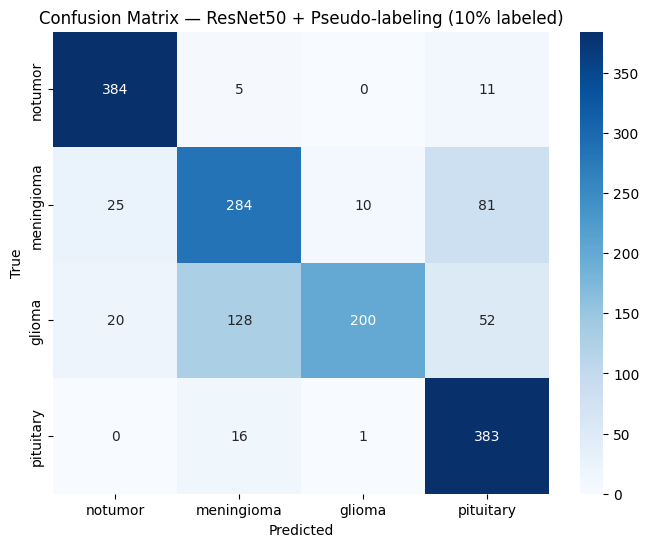

              precision    recall  f1-score   support

     notumor       0.90      0.96      0.93       400
  meningioma       0.66      0.71      0.68       400
      glioma       0.95      0.50      0.65       400
   pituitary       0.73      0.96      0.83       400

    accuracy                           0.78      1600
   macro avg       0.81      0.78      0.77      1600
weighted avg       0.81      0.78      0.77      1600



In [ ]:
# ============================================================
# CELL 8 — Final evaluation
# ============================================================
from sklearn.metrics import confusion_matrix, classification_report

all_preds, all_true = [], []
for imgs, labels in test_ds:
    preds = model.predict(imgs, verbose=0)
    all_preds.extend(np.argmax(preds, axis=1))
    all_true.extend(np.argmax(labels.numpy(), axis=1))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.title('Confusion Matrix — ResNet50 + Pseudo-labeling (10% labeled)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

print(classification_report(all_true, all_preds, target_names=CLASSES))

In [ ]:
# Smart iterative pseudo-labeling
# Round 3 — lower threshold gradually as model gets more confident

for round_num, threshold in enumerate([0.88, 0.85, 0.80], start=3):
    print(f"\n Round {round_num} — threshold: {threshold}")

    # Predict on unlabeled
    unlabeled_ds_ordered = build_dataset(unlabeled_df, labeled=False, augment=False)
    preds      = model.predict(unlabeled_ds_ordered, verbose=0)
    confidence = np.max(preds, axis=1)
    plabels    = np.argmax(preds, axis=1)

    print(f"   Passing threshold: {np.sum(confidence > threshold)}")

    # Build combined dataset
    mask = confidence > threshold
    pseudo = pd.DataFrame({
        'filename': unlabeled_df['filename'].values[mask],
        'class':    [CLASSES[i] for i in plabels[mask]]
    })
    combined = pd.concat([labeled_df, pseudo], ignore_index=True)
    print(f"   Combined size: {len(combined)}")
    print(combined['class'].value_counts().to_dict())

    # Retrain
    combined_ds = build_dataset(combined, labeled=True, augment=True)
    model.fit(
        combined_ds, epochs=10,
        validation_data=test_ds,
        callbacks=callbacks, verbose=0
    )

    loss, acc = model.evaluate(test_ds, verbose=0)
    print(f"    Accuracy: {acc*100:.2f}%")


 Round 3 — threshold: 0.88
   Passing threshold: 4588
   Combined size: 5148
{'pituitary': 1597, 'meningioma': 1385, 'notumor': 1244, 'glioma': 922}

Epoch 1: val_loss did not improve from 0.91235

Epoch 2: val_loss did not improve from 0.91235

Epoch 3: ReduceLROnPlateau reducing learning rate to 1.968299789822936e-09.

Epoch 3: val_loss did not improve from 0.91235

Epoch 4: val_loss did not improve from 0.91235

Epoch 5: val_loss did not improve from 0.91235
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
    Accuracy: 78.12%

 Round 4 — threshold: 0.85
   Passing threshold: 4630
   Combined size: 5190
{'pituitary': 1610, 'meningioma': 1400, 'notumor': 1248, 'glioma': 932}

Epoch 1: val_loss did not improve from 0.91235

Epoch 2: val_loss did not improve from 0.91235

Epoch 3: ReduceLROnPlateau reducing learning rate to 5.904899236242044e-10.

Epoch 3: val_loss did not improve from 0.91235

Epoch 4: val_loss did not improve from 0.91235

Epoch 5: 

FixMatch Implementation

In [ ]:
# ============================================================
# CELL 1 — Setup + unzip (same as before)
# ============================================================
import tensorflow as tf
import pandas as pd
import numpy as np
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import zipfile, glob, os
import matplotlib.pyplot as plt
import seaborn as sns

zip_files = glob.glob('/content/*.zip')
with zipfile.ZipFile(zip_files[0], 'r') as z:
    z.extractall('/content/dataset')

CLASSES      = ['notumor', 'meningioma', 'glioma', 'pituitary']
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
DATASET_PATH = '/content/dataset'

print("GPU:", tf.config.list_physical_devices('GPU'))
print(" Setup done")

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
 Setup done


In [ ]:
# ============================================================
# CELL 2 — File paths + 10% labeled split
# ============================================================
base_datagen = ImageDataGenerator(rescale=1./255)

train_gen = base_datagen.flow_from_directory(
    f'{DATASET_PATH}/Training',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASSES, shuffle=False
)
test_gen = base_datagen.flow_from_directory(
    f'{DATASET_PATH}/Testing',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=CLASSES, shuffle=False
)

labeled_idx, unlabeled_idx = train_test_split(
    np.arange(len(train_gen.filepaths)),
    test_size=0.90,
    stratify=train_gen.labels,
    random_state=42
)

labeled_df = pd.DataFrame({
    'filename': [train_gen.filepaths[i] for i in labeled_idx],
    'class':    [CLASSES[train_gen.labels[i]] for i in labeled_idx]
})
unlabeled_df = pd.DataFrame({
    'filename': [train_gen.filepaths[i] for i in unlabeled_idx],
    'class':    [CLASSES[train_gen.labels[i]] for i in unlabeled_idx]
})
test_df = pd.DataFrame({
    'filename': test_gen.filepaths,
    'class':    [CLASSES[l] for l in test_gen.labels]
})

print(f" Labeled:   {len(labeled_df)}")
print(f" Unlabeled: {len(unlabeled_df)}")
print(f" Test:      {len(test_df)}")

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
 Labeled:   560
 Unlabeled: 5040
 Test:      1600


In [ ]:
# ============================================================
# CELL 3 — Weak + Strong augmentation datasets
# ============================================================
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = preprocess_input(img)
    return img

def weak_augment(img):
    img = tf.image.random_flip_left_right(img)
    return img

def strong_augment(img):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.3)
    img = tf.image.random_contrast(img, 0.7, 1.3)
    img = tf.image.random_saturation(img, 0.7, 1.3)
    img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
    return img

def build_labeled_ds(dataframe, batch_size=32):
    filepaths = dataframe['filename'].values
    labels    = [CLASSES.index(c) for c in dataframe['class'].values]

    ds = tf.data.Dataset.from_tensor_slices(filepaths)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(weak_augment, num_parallel_calls=tf.data.AUTOTUNE)

    label_ds = tf.data.Dataset.from_tensor_slices(
        tf.keras.utils.to_categorical(labels, 4)
    )
    ds = tf.data.Dataset.zip((ds, label_ds))
    ds = ds.shuffle(500).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

def build_unlabeled_ds(dataframe, batch_size=32):
    filepaths = dataframe['filename'].values

    ds = tf.data.Dataset.from_tensor_slices(filepaths)

    # Weak augmented version
    weak_ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    weak_ds = weak_ds.map(weak_augment, num_parallel_calls=tf.data.AUTOTUNE)

    # Strong augmented version of same images
    strong_ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    strong_ds = strong_ds.map(strong_augment, num_parallel_calls=tf.data.AUTOTUNE)

    # Zip weak + strong together
    ds = tf.data.Dataset.zip((weak_ds, strong_ds))
    ds = ds.shuffle(500).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

def build_test_ds(dataframe, batch_size=32):
    filepaths = dataframe['filename'].values
    labels    = [CLASSES.index(c) for c in dataframe['class'].values]

    ds = tf.data.Dataset.from_tensor_slices(filepaths)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    label_ds = tf.data.Dataset.from_tensor_slices(
        tf.keras.utils.to_categorical(labels, 4)
    )
    ds = tf.data.Dataset.zip((ds, label_ds))
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

labeled_ds   = build_labeled_ds(labeled_df)
unlabeled_ds = build_unlabeled_ds(unlabeled_df)
test_ds      = build_test_ds(test_df)

print(" All datasets ready")

 All datasets ready


In [ ]:
# ============================================================
# CELL 4 — ResNet50 model
# ============================================================
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Unfreeze last 30 layers from start
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers[-30:]:
    layer.trainable = True

inputs  = base_model.input
x       = layers.GlobalAveragePooling2D()(base_model.output)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model = Model(inputs, outputs)
optimizer = tf.keras.optimizers.Adam(1e-4)

print(" ResNet50 ready")

 ResNet50 ready


In [ ]:
# ============================================================
# CELL 5 — FixMatch custom training loop
# ============================================================
CONFIDENCE_THRESHOLD = 0.95
LAMBDA_U = 1.0       # weight of unlabeled loss
EPOCHS   = 30
STEPS_PER_EPOCH = len(labeled_ds)

# Loss functions
supervised_loss_fn   = tf.keras.losses.CategoricalCrossentropy()
unsupervised_loss_fn = tf.keras.losses.CategoricalCrossentropy()

@tf.function
def train_step(labeled_batch, unlabeled_batch):
    labeled_imgs, labels     = labeled_batch
    weak_imgs,    strong_imgs = unlabeled_batch

    with tf.GradientTape() as tape:
        # Supervised loss on labeled data
        labeled_preds = model(labeled_imgs, training=True)
        loss_s = supervised_loss_fn(labels, labeled_preds)

        # Pseudo labels from weak augmented unlabeled
        weak_preds   = model(weak_imgs, training=False)
        pseudo_conf  = tf.reduce_max(weak_preds, axis=1)
        pseudo_labels = tf.one_hot(tf.argmax(weak_preds, axis=1), 4)

        # Mask — only keep high confidence predictions
        mask = tf.cast(pseudo_conf >= CONFIDENCE_THRESHOLD, tf.float32)

        # Consistency loss on strongly augmented unlabeled
        strong_preds = model(strong_imgs, training=True)
        loss_u = unsupervised_loss_fn(pseudo_labels, strong_preds)
        loss_u = tf.reduce_mean(loss_u * mask)

        # Total loss
        total_loss = loss_s + LAMBDA_U * loss_u

    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    return loss_s, loss_u, tf.reduce_mean(mask)

# Evaluation function
def evaluate(dataset):
    correct, total = 0, 0
    for imgs, labels in dataset:
        preds = model(imgs, training=False)
        correct += tf.reduce_sum(
            tf.cast(tf.equal(tf.argmax(preds, 1), tf.argmax(labels, 1)), tf.float32)
        ).numpy()
        total += len(imgs)
    return correct / total

# Training loop
best_acc = 0
unlabeled_iter = iter(unlabeled_ds.repeat())

print(" FixMatch Training...")
print(f"{'Epoch':>6} {'S_Loss':>8} {'U_Loss':>8} {'Mask%':>7} {'Val_Acc':>8}")
print("-" * 45)

for epoch in range(EPOCHS):
    s_losses, u_losses, masks = [], [], []

    for labeled_batch in labeled_ds:
        unlabeled_batch = next(unlabeled_iter)
        ls, lu, mask = train_step(labeled_batch, unlabeled_batch)
        s_losses.append(ls.numpy())
        u_losses.append(lu.numpy())
        masks.append(mask.numpy())

    val_acc = evaluate(test_ds)

    print(f"{epoch+1:>6} {np.mean(s_losses):>8.4f} {np.mean(u_losses):>8.4f} "
          f"{np.mean(masks)*100:>6.1f}% {val_acc*100:>7.2f}%")

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        model.save('/content/best_fixmatch.keras')

print(f"\n Best FixMatch Accuracy: {best_acc*100:.2f}%")

 FixMatch Training...
 Epoch   S_Loss   U_Loss   Mask%  Val_Acc
---------------------------------------------
     1   0.8452   0.0845    6.9%   60.69%
     2   0.1896   0.2941   34.7%   71.00%
     3   0.0813   0.2658   52.3%   77.38%
     4   0.0809   0.2554   64.9%   72.06%
     5   0.0434   0.2466   76.6%   79.88%
     6   0.0440   0.2753   74.0%   77.50%
     7   0.0454   0.2784   74.1%   81.56%
     8   0.0370   0.2901   80.4%   80.75%
     9   0.0572   0.3303   80.4%   79.31%
    10   0.0187   0.2902   83.9%   77.38%
    11   0.0450   0.2675   88.2%   79.19%
    12   0.0483   0.1759   87.2%   79.12%
    13   0.0468   0.2503   82.5%   80.44%
    14   0.0316   0.2353   86.3%   81.12%
    15   0.0198   0.1882   87.0%   81.25%
    16   0.0109   0.2338   87.3%   80.06%
    17   0.0431   0.2627   87.3%   74.88%
    18   0.0733   0.2830   81.6%   78.12%
    19   0.0467   0.2089   87.0%   79.38%
    20   0.0284   0.1154   87.8%   81.25%
    21   0.0108   0.1728   89.2%   81.88%
    22  

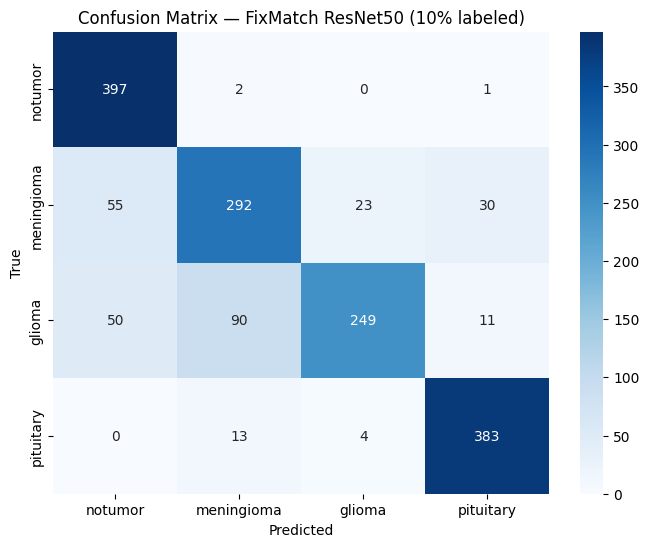

              precision    recall  f1-score   support

     notumor       0.79      0.99      0.88       400
  meningioma       0.74      0.73      0.73       400
      glioma       0.90      0.62      0.74       400
   pituitary       0.90      0.96      0.93       400

    accuracy                           0.83      1600
   macro avg       0.83      0.83      0.82      1600
weighted avg       0.83      0.83      0.82      1600



In [ ]:
# ============================================================
# CELL 6 — Final evaluation
# ============================================================
from sklearn.metrics import confusion_matrix, classification_report

model = tf.keras.models.load_model('/content/best_fixmatch.keras')

all_preds, all_true = [], []
for imgs, labels in test_ds:
    preds = model.predict(imgs, verbose=0)
    all_preds.extend(np.argmax(preds, axis=1))
    all_true.extend(np.argmax(labels.numpy(), axis=1))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.title('Confusion Matrix — FixMatch ResNet50 (10% labeled)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

print(classification_report(all_true, all_preds, target_names=CLASSES))